# Notebook 02: Exploratory Data Analysis & Market Intelligence
## Cambodian Second-Hand Vehicle Market — Clean Dataset Analysis

> **Project**: Cambodia Used Car Price Prediction  
> **Institution**: ITC — Department of Applied Mathematics and Statistics (AMS)  
> **Source Data**: `data/processed/cars_clean.parquet` (Silver Layer — deduplicated & sanity-filtered)  
> **Architecture**: Medallion Pattern (Bronze -> Silver -> Gold)  

---

## Objectives
1. **Load Clean Silver Dataset** — consume `cars_clean.parquet` directly, no inline re-cleaning.  
2. **Data Quality Audit** — schema, dtypes, null counts, sample values.  
3. **Feature Engineering** — domain proxies: vehicle age, brand tiers, location tiers, NLP keyword flags.  
4. **Target Variable Analysis** — price distribution, log-transform normality check (histogram + Q-Q plot).  
5. **Univariate Market Landscape** — manufacturing year, brand market shares, tax status, geography.  
6. **Bivariate & Model-Level Dynamics** — depreciation curves, top-10 model price spreads, Prius/RX300/Highlander comparison.  
7. **Market Liquidity Analysis** — days-on-market, view count, seller type dynamics.  
8. **Statistical Hypothesis Tests** — Mann-Whitney U, Kruskal-Wallis H.  
9. **Correlation Analysis & Feature Ranking** — Pearson heatmap vs `log_price`.  
10. **Executive Summary** — key findings & hand-off to Phase 4 Modeling.


In [1]:
# ── 1. Setup & Imports ────────────────────────────────────────────────────────
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# ── Visual Styling ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "figure.dpi":         120,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
    "figure.facecolor":   "white",
})

# ── Project Paths ──────────────────────────────────────────────────────────────
NB_DIR       = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NB_DIR, "..")) if "notebooks" in NB_DIR else NB_DIR
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
REPORTS_DIR   = os.path.join(PROJECT_ROOT, "reports")
os.makedirs(REPORTS_DIR, exist_ok=True)

print("Setup complete.")
print(f"  Project root   : {PROJECT_ROOT}")
print(f"  Processed data : {PROCESSED_DIR}")
print(f"  Reports dir    : {REPORTS_DIR}")


Setup complete.
  Project root   : D:\ITC3_AMS_2025\I4_AMS_S2\Y4_Internship\Car_price_prediction
  Processed data : D:\ITC3_AMS_2025\I4_AMS_S2\Y4_Internship\Car_price_prediction\data\processed
  Reports dir    : D:\ITC3_AMS_2025\I4_AMS_S2\Y4_Internship\Car_price_prediction\reports


---
## 2. Load Silver Clean Dataset (`cars_clean.parquet`)

The Silver Layer dataset was produced by the ETL pipeline (`pipeline/transform.py`) which:
- Deduplicated 9 daily snapshot partitions to the **latest listing state** per `listing_id`.
- Applied **sanity bounds filtering**: $500 \le \text{price} \le \$300{,}000$ and $1990 \le \text{year} \le 2027$.
- Re-extracted brands/models using the multilingual NLP parser on listing titles.

> We load this file directly — no inline re-cleaning is needed.


In [2]:
# ── 2. Load Clean Dataset ─────────────────────────────────────────────────────
clean_path = os.path.join(PROCESSED_DIR, "cars_clean.parquet")
if not os.path.exists(clean_path):
    raise FileNotFoundError(
        f"Clean dataset not found at '{clean_path}'.\n"
        "Run:  uv run python -m pipeline.transform  (or Makefile: make transform)"
    )

df = pd.read_parquet(clean_path)

# Parse dates
for col in ["posted_at", "scraped_at"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

print("=" * 65)
print(f"Loaded: {len(df):,} rows x {df.shape[1]} columns")
print("=" * 65)
print(f"  Unique listing IDs     : {df['listing_id'].nunique():,}")
print(f"  Price range            : ${df['price'].min():,.0f}  to  ${df['price'].max():,.0f}")
print(f"  Model year range       : {int(df['vehicle_model_year'].min())}  to  {int(df['vehicle_model_year'].max())}")
print(f"  Brands identified      : {df[df['vehicle_brand'] != 'Unknown']['vehicle_brand'].nunique()}")
if "posted_at" in df.columns and df["posted_at"].notna().any():
    print(f"  Listing date range     : {df['posted_at'].min().strftime('%Y-%m-%d')}  to  {df['posted_at'].max().strftime('%Y-%m-%d')}")
print("=" * 65)


Loaded: 3,330 rows x 21 columns
  Unique listing IDs     : 3,330
  Price range            : $500  to  $298,000
  Model year range       : 1990  to  2027
  Brands identified      : 53
  Listing date range     : 2026-02-03  to  2026-08-25


---
## 3. Data Quality Audit — Schema, Nulls & Sample Values


In [9]:
# ── 3a. Missingness Profiling Table ───────────────────────────────────────────                                                     
missing_counts = df.isnull().sum()                                                                                                   
missing_pcts   = (missing_counts / len(df) * 100).round(1)                                                                           
                                                                                                                                        
df_missing = pd.DataFrame({                                                                                                          
    "Missing Count":    missing_counts,                                                                                              
    "Missing %":        missing_pcts,                                                                                                
    "Non-Null Count":   len(df) - missing_counts,                                                                                    
    "Unique Values":    df.nunique(),                                                                                                
    "dtype":            df.dtypes,                                                                                                   
    "Sample Values":    [", ".join(str(v) for v in df[c].dropna().unique()[:3])                                                      
                            for c in df.columns],                                                                                       
}).sort_values("Missing Count", ascending=False)                                                                                     
print(f"Dataset : {len(df):,} rows x {df.shape[1]} columns")                                                                         
                                                                                                                                        
print(f"Complete columns : {(df_missing['Missing Count'] == 0).sum()} / {len(df_missing)}")                                          
print(f"Columns with nulls : {(df_missing['Missing Count'] > 0).sum()} / {len(df_missing)}")                                         
print()                                                                                                                              
print("Top Missing Features in Clean Silver Dataset:")                                                                               
display(df_missing[df_missing["Missing Count"] > 0])

Dataset : 3,330 rows x 21 columns
Complete columns : 19 / 21
Columns with nulls : 2 / 21

Top Missing Features in Clean Silver Dataset:


,Missing Count,Missing %,Non-Null Count,Unique Values,dtype,Sample Values
vehicle_engine_cc,3330,100.0,0,0,float64,
vehicle_mileage_km,3330,100.0,0,0,float64,


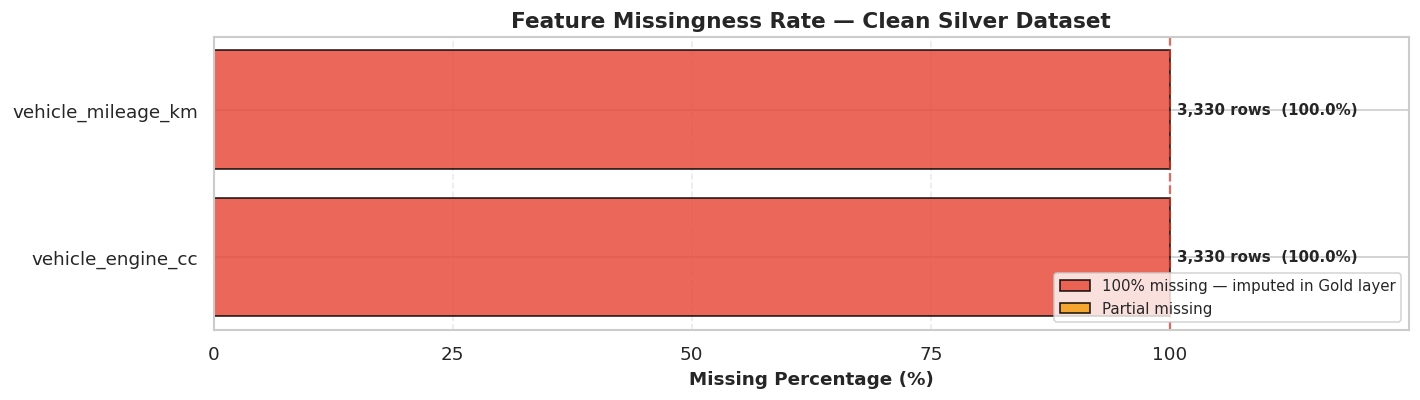

In [10]:
# ── 3b. Missing Value Bar Chart ───────────────────────────────────────────────                                                     
plot_data = (                                                                                                                        
    df_missing[df_missing["Missing %"] > 0]["Missing %"]                                                                             
    .sort_values(ascending=True)                                                                                                     
)                                                                                                                                    
                                                                                                                                        
plt.figure(figsize=(12, max(3.5, len(plot_data) * 1.1)))                                                                             
                                                                                                                                        
bar_colors = ["#e74c3c" if p == 100.0 else "#f39c12" for p in plot_data.values]                                                      
bars = plt.barh(                                                                                                                     
    plot_data.index, plot_data.values,                                                                                               
    color=bar_colors, edgecolor="black", alpha=0.85                                                                                  
)                                                                                                                                    
                                                                                                                                        
for bar in bars:                                                                                                                     
    w = bar.get_width()                                                                                                              
    col_name = plot_data.index[list(plot_data.values).index(w)]                                                                      
    cnt = int(df_missing.loc[col_name, "Missing Count"])                                                                             
    plt.text(                                                                                                                        
        w + 0.8,                                                                                                                     
        bar.get_y() + bar.get_height() / 2,                                                                                          
        f"{cnt:,} rows  ({w:.1f}%)",                                                                                                 
        va="center", fontsize=9, fontweight="bold"                                                                                   
    )                                                                                                                                
                                                                                                                                        
plt.xlabel("Missing Percentage (%)", fontweight="bold")                                                                              
plt.title("Feature Missingness Rate — Clean Silver Dataset", fontweight="bold", fontsize=13)                                         
plt.xlim(0, 125)                                                                                                                     
plt.xticks([0, 25, 50, 75, 100])                                                                                                     
plt.axvline(100, color="#c0392b", ls="--", lw=1.4, alpha=0.7, label="100% threshold")                                                
plt.grid(axis="x", linestyle="--", alpha=0.4)                                                                                        
                                                                                                                                        
from matplotlib.patches import Patch                                                                                                 
plt.legend(handles=[                                                                                                                 
    Patch(facecolor="#e74c3c", edgecolor="black", alpha=0.85,                                                                        
            label="100% missing — imputed in Gold layer"),                                                                             
    Patch(facecolor="#f39c12", edgecolor="black", alpha=0.85,                                                                        
            label="Partial missing"),                                                                                                  
], fontsize=9, loc="lower right")                                                                                                    
                                                                                                                                        
plt.tight_layout()                                                                                                                   
plt.show()    

---
## 4. Feature Engineering & Domain Segmentation

We construct high-signal predictive features:

| Feature | Description |
|---|---|
| `vehicle_age` | `2026 - vehicle_model_year` (clipped ≥ 0) |
| `vehicle_age_squared` | Quadratic depreciation term |
| `log_price` | `ln(1 + price)` — stabilises variance for regression |
| `is_mileage_missing` | Binary flag for missing odometer data |
| `brand_tier` | Luxury / Popular / Chinese_EV / Other |
| `location_tier` | Tier 1 (Phnom Penh) / Tier 2 (regional hubs) / Tier 3 (other) |
| `is_plate_number` | 1 if tax type == "Plate Number" |
| `has_full_option` | NLP flag from listing title |
| `has_sunroof_solar` | NLP flag from listing title |
| `is_urgent_sale` | NLP flag from listing title |


In [5]:
# ── 4. Feature Engineering ────────────────────────────────────────────────────
CURRENT_YEAR = 2026

df_eda = df.copy()

# ── Temporal & Depreciation ────────────────────────────────────────────────────
df_eda["vehicle_age"]         = (CURRENT_YEAR - df_eda["vehicle_model_year"]).clip(lower=0)
df_eda["vehicle_age_squared"] = df_eda["vehicle_age"] ** 2
df_eda["is_mileage_missing"]  = df_eda["vehicle_mileage_km"].isna().astype(int)
df_eda["imputed_mileage_km"]  = df_eda["vehicle_mileage_km"].fillna(100_000.0)
df_eda["mileage_per_year"]    = df_eda["imputed_mileage_km"] / (df_eda["vehicle_age"] + 1.0)

# ── Log-Price Target ──────────────────────────────────────────────────────────
df_eda["log_price"] = np.log1p(df_eda["price"])

# ── Brand Tiers ───────────────────────────────────────────────────────────────
LUXURY_BRANDS     = {"Lexus","Mercedes-Benz","BMW","Porsche","Land Rover","Audi",
                     "Cadillac","Rolls-Royce","Bentley","Genesis","Maserati"}
POPULAR_BRANDS    = {"Toyota","Ford","Hyundai","Kia","Mazda","Honda",
                     "Mitsubishi","Nissan","Suzuki"}
CHINESE_EV_BRANDS = {"BYD","Denza","MG","Geely","Haval","GAC","Jetour","Changan",
                     "Zeekr","Li Auto","Fangchengbao","iCar","Xpeng","NIO"}

def brand_tier(b):
    if b in LUXURY_BRANDS:     return "Luxury"
    if b in POPULAR_BRANDS:    return "Popular"
    if b in CHINESE_EV_BRANDS: return "Chinese EV"
    return "Other"

df_eda["brand_tier"]         = df_eda["vehicle_brand"].apply(brand_tier)
df_eda["is_luxury_brand"]    = df_eda["vehicle_brand"].isin(LUXURY_BRANDS).astype(int)
df_eda["is_popular_brand"]   = df_eda["vehicle_brand"].isin(POPULAR_BRANDS).astype(int)
df_eda["is_chinese_ev"]      = df_eda["vehicle_brand"].isin(CHINESE_EV_BRANDS).astype(int)

# ── Location Tiers ─────────────────────────────────────────────────────────────
TIER_1 = {"Phnom Penh"}
TIER_2 = {"Siem Reap","Battambang","Kandal","Preah Sihanouk","Kampong Cham"}

def loc_tier(p):
    if p in TIER_1: return "Tier 1"
    if p in TIER_2: return "Tier 2"
    return "Tier 3"

df_eda["location_tier"] = df_eda["province"].apply(loc_tier)
df_eda["is_tier1_loc"]  = (df_eda["location_tier"] == "Tier 1").astype(int)
df_eda["is_plate_number"] = (df_eda["vehicle_tax_type"] == "Plate Number").astype(int)

# ── NLP Keyword Flags ─────────────────────────────────────────────────────────
titles = df_eda["listing_title"].astype(str).str.lower()
df_eda["has_full_option"]   = titles.str.contains(
    r"full\s*option|f-sport|limited|platinum|wildtrak|raptor|amg", regex=True).astype(int)
df_eda["has_sunroof_solar"] = titles.str.contains(
    r"solar|sunroof|moonroof|open\s*roof", regex=True).astype(int)
df_eda["has_leather_seats"] = titles.str.contains(
    r"leather", regex=True).astype(int)
df_eda["is_urgent_sale"]    = titles.str.contains(
    r"urgent|negotiable", regex=True).astype(int)

print(f"Feature engineering complete: {df_eda.shape[0]:,} rows x {df_eda.shape[1]} columns")

# Quick summary of new flags
flag_cols = ["has_full_option","has_sunroof_solar","has_leather_seats","is_urgent_sale","is_plate_number"]
flag_summary = pd.DataFrame({
    "Flag": flag_cols,
    "Count": [df_eda[c].sum() for c in flag_cols],
    "Pct %": [round(df_eda[c].mean()*100, 1) for c in flag_cols],
})
display(flag_summary.to_string(index=False))


Feature engineering complete: 3,330 rows x 38 columns


'             Flag  Count  Pct %\n  has_full_option    507   15.2\nhas_sunroof_solar     13    0.4\nhas_leather_seats      0    0.0\n   is_urgent_sale     19    0.6\n  is_plate_number   2295   68.9'

---
## 5. Target Variable Analysis: Price (USD) & Log Transformation

Vehicle prices in Cambodia exhibit **severe right skewness** — a small number of luxury vehicles
pull the mean far above the median. The log-transform $\ln(1+\text{price})$ creates a near-Gaussian
distribution that stabilises MSE loss for regression models.


Car Price (USD) — Statistical Summary:
  Count               : 3,330
  Mean                : $31,165
  Median (50%)        : $21,500
  Std Dev             : $33,467
  Min                 : $500
  25th Pctile         : $13,800
  75th Pctile         : $36,500
  90th Pctile         : $56,710
  99th Pctile         : $194,710
  Max                 : $298,000
  Raw Skewness        : 3.668
  Log Skewness        : 0.103


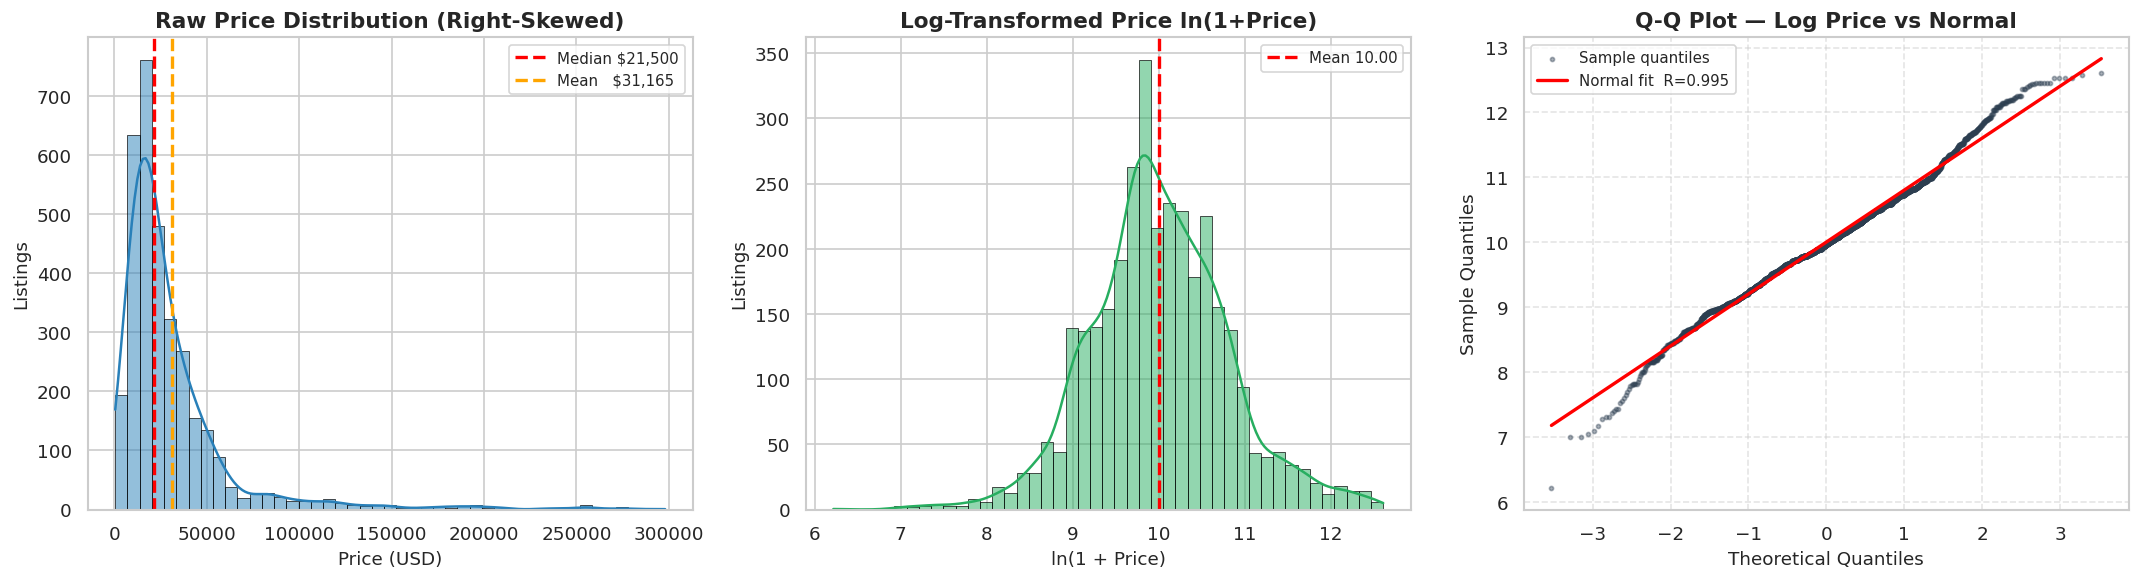

In [ ]:
# ── 5. Target Variable Distribution & Normality ───────────────────────────────
pstats = df_eda["price"].describe(percentiles=[.05,.25,.50,.75,.90,.99])

print("=" * 56)
print("Car Price (USD) — Statistical Summary:")
print("=" * 56)
for label, key in [
    ("Count",           "count"),
    ("Mean",            "mean"),
    ("Median (50%)",    "50%"),
    ("Std Dev",         "std"),
    ("Min",             "min"),
    ("25th Pctile",     "25%"),
    ("75th Pctile",     "75%"),
    ("90th Pctile",     "90%"),
    ("99th Pctile",     "99%"),
    ("Max",             "max"),
]:
    val = pstats[key]
    if key == "count":
        print(f"  {label:<20}: {int(val):,}")
    else:
        print(f"  {label:<20}: ${val:,.0f}")
print(f"  {'Raw Skewness':<20}: {df_eda['price'].skew():.3f}")
print(f"  {'Log Skewness':<20}: {df_eda['log_price'].skew():.3f}")
print("=" * 56)

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Raw price histogram
ax = axes[0]
sns.histplot(df_eda["price"], bins=45, kde=True, ax=ax, color="#2980b9", edgecolor="black", linewidth=0.4)
ax.axvline(df_eda["price"].median(), color="red",    ls="--", lw=2, label=f"Median ${df_eda['price'].median():,.0f}")
ax.axvline(df_eda["price"].mean(),   color="orange", ls="--", lw=2, label=f"Mean   ${df_eda['price'].mean():,.0f}")
ax.set_title("Raw Price Distribution (Right-Skewed)")
ax.set_xlabel("Price (USD)"); ax.set_ylabel("Listings"); ax.legend(fontsize=9)

# 2. Log-price histogram
ax = axes[1]
sns.histplot(df_eda["log_price"], bins=45, kde=True, ax=ax, color="#27ae60", edgecolor="black", linewidth=0.4)
ax.axvline(df_eda["log_price"].mean(), color="red", ls="--", lw=2,
           label=f"Mean {df_eda['log_price'].mean():.2f}")
ax.set_title("Log-Transformed Price ln(1+Price)")
ax.set_xlabel("ln(1 + Price)"); ax.set_ylabel("Listings"); ax.legend(fontsize=9)

# 3. Q-Q plot
ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(df_eda["log_price"], dist="norm")
ax.scatter(osm, osr, s=6, alpha=0.4, color="#2c3e50", label="Sample quantiles")
ax.plot(osm, slope*np.array(osm)+intercept, color="red", lw=2, label=f"Normal fit  R={r:.3f}")
ax.set_title("Q-Q Plot — Log Price vs Normal")
ax.set_xlabel("Theoretical Quantiles"); ax.set_ylabel("Sample Quantiles")
ax.legend(fontsize=9); ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
# plt.savefig(os.path.join(REPORTS_DIR, "01_price_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## 6. Univariate Market Landscape

We profile the key categorical and numeric attributes of the Cambodian marketplace.


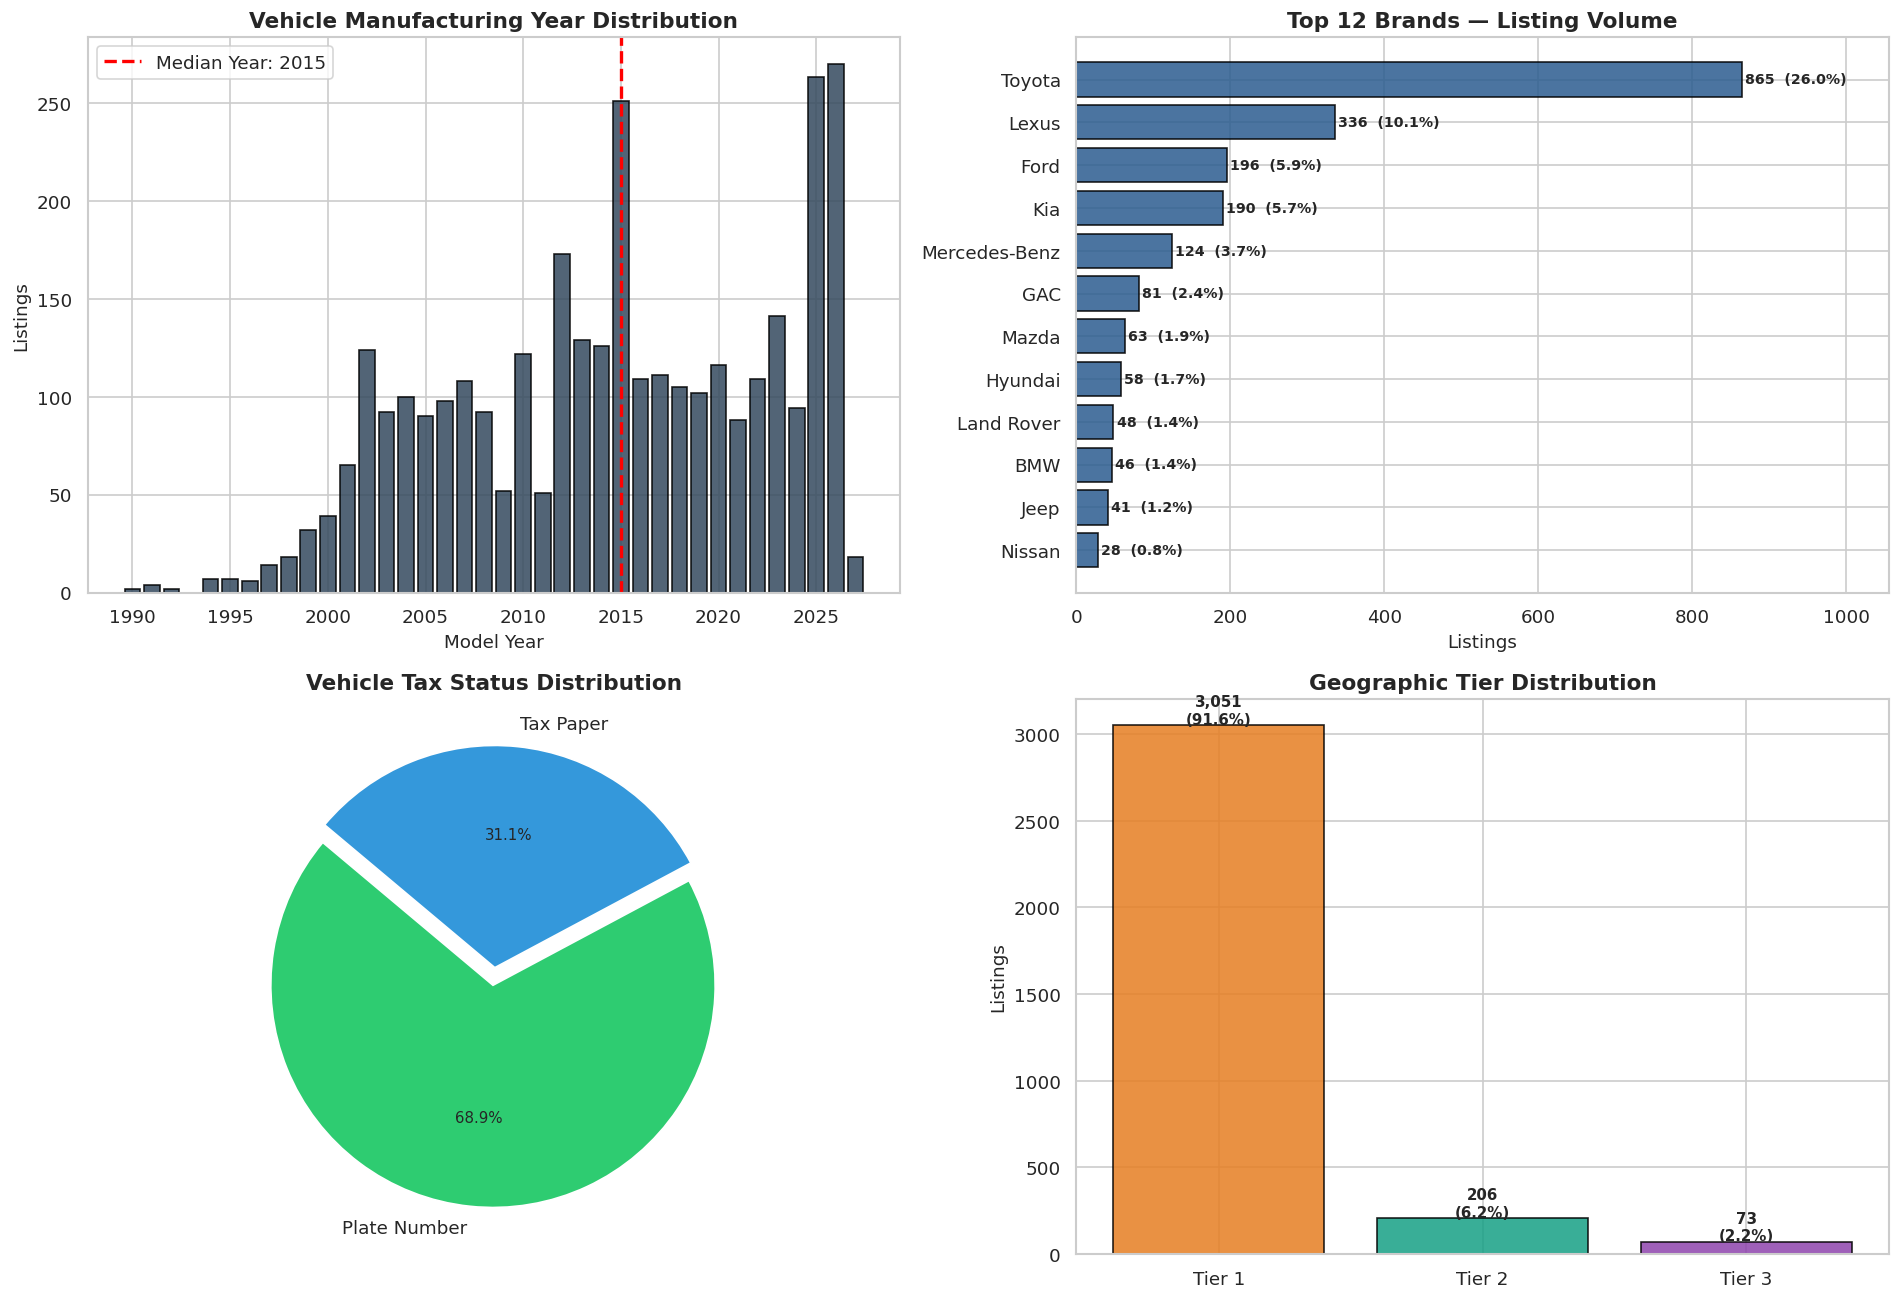

In [ ]:
# ── 6. Univariate Analysis ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── 6a. Manufacturing Year ─────────────────────────────────────────────────────
ax = axes[0, 0]
yr_counts = df_eda["vehicle_model_year"].value_counts().sort_index()
ax.bar(yr_counts.index, yr_counts.values, color="#34495e", edgecolor="black", alpha=0.85, width=0.8)
ax.axvline(df_eda["vehicle_model_year"].median(), color="red", ls="--", lw=2,
           label=f"Median Year: {int(df_eda['vehicle_model_year'].median())}")
ax.set_title("Vehicle Manufacturing Year Distribution")
ax.set_xlabel("Model Year"); ax.set_ylabel("Listings"); ax.legend()

# ── 6b. Top 12 Brands ─────────────────────────────────────────────────────────
ax = axes[0, 1]
top12 = df_eda[df_eda["vehicle_brand"] != "Unknown"]["vehicle_brand"].value_counts().head(12)
bars = ax.barh(top12.index[::-1], top12.values[::-1], color="#2b5c8f", edgecolor="black", alpha=0.85)
for i, v in enumerate(top12.values[::-1]):
    ax.text(v + 4, i, f"{v:,}  ({v/len(df_eda)*100:.1f}%)", va="center", fontsize=8.5, fontweight="bold")
ax.set_title("Top 12 Brands — Listing Volume")
ax.set_xlabel("Listings"); ax.set_xlim(right=top12.max() * 1.22)

# ── 6c. Tax Type ──────────────────────────────────────────────────────────────
ax = axes[1, 0]
tax_counts = df_eda["vehicle_tax_type"].value_counts()
colors = ["#2ecc71","#3498db","#f39c12","#95a5a6","#e74c3c"]
wedges, texts, autotexts = ax.pie(
    tax_counts.values, labels=tax_counts.index,
    autopct="%1.1f%%", colors=colors[:len(tax_counts)],
    startangle=140, explode=[0.04]*len(tax_counts)
)
for at in autotexts: at.set_fontsize(9)
ax.set_title("Vehicle Tax Status Distribution")

# ── 6d. Location Tier ─────────────────────────────────────────────────────────
ax = axes[1, 1]
loc_counts = df_eda["location_tier"].value_counts().reindex(["Tier 1","Tier 2","Tier 3"])
bar_colors = ["#e67e22","#16a085","#8e44ad"]
ax.bar(loc_counts.index, loc_counts.values, color=bar_colors, edgecolor="black", alpha=0.85)
for i, v in enumerate(loc_counts.values):
    ax.text(i, v + 8, f"{v:,}\n({v/len(df_eda)*100:.1f}%)", ha="center", fontweight="bold", fontsize=9)
ax.set_title("Geographic Tier Distribution")
ax.set_ylabel("Listings")

plt.tight_layout()
# plt.savefig(os.path.join(REPORTS_DIR, "02_univariate_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## 7. Depreciation Analysis

### 7a. Overall Market Depreciation Curve  
Median price (with IQR band) as a function of manufacturing year, and the linearised
decay of `log_price` against vehicle age.


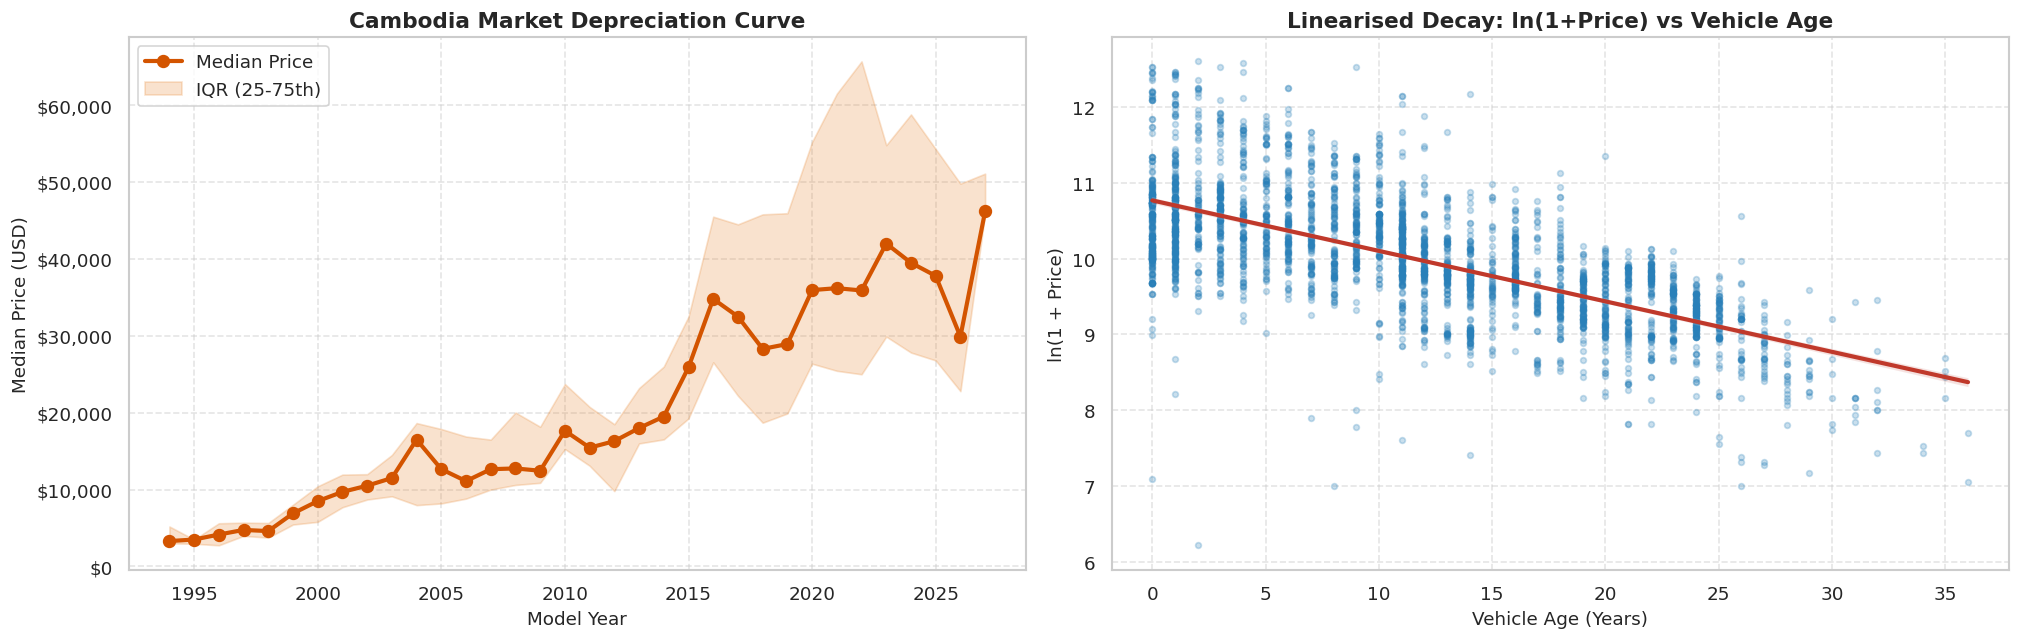

In [ ]:
# ── 7a. Overall Depreciation Curve ───────────────────────────────────────────
yr_stats = (
    df_eda.groupby("vehicle_model_year")["price"]
    .agg(median="median", q25=lambda x: np.percentile(x, 25),
         q75=lambda x: np.percentile(x, 75), n="count")
    .reset_index()
)
yr_stats = yr_stats[yr_stats["n"] >= 5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5.5))

# 1. Median price vs year
ax1.plot(yr_stats["vehicle_model_year"], yr_stats["median"],
         marker="o", color="#d35400", lw=2.5, ms=7, label="Median Price")
ax1.fill_between(yr_stats["vehicle_model_year"], yr_stats["q25"], yr_stats["q75"],
                 color="#e67e22", alpha=0.22, label="IQR (25-75th)")
ax1.set_title("Cambodia Market Depreciation Curve")
ax1.set_xlabel("Model Year"); ax1.set_ylabel("Median Price (USD)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.grid(True, ls="--", alpha=0.5); ax1.legend()

# 2. Log-price vs vehicle age (regression line)
sns.regplot(data=df_eda, x="vehicle_age", y="log_price", ax=ax2,
            scatter_kws={"alpha": 0.25, "color": "#2980b9", "s": 12},
            line_kws={"color": "#c0392b", "lw": 2.5})
ax2.set_title("Linearised Decay: ln(1+Price) vs Vehicle Age")
ax2.set_xlabel("Vehicle Age (Years)"); ax2.set_ylabel("ln(1 + Price)")
ax2.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
# plt.savefig(os.path.join(REPORTS_DIR, "03_depreciation_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


### 7b. Top-10 Model Price Spread & Model Depreciation Comparison

We zoom in to the individual **model level** — how do specific Toyota, Lexus, Ford, and Kia
models differ in price, and how do the three highest-volume models depreciate over time?


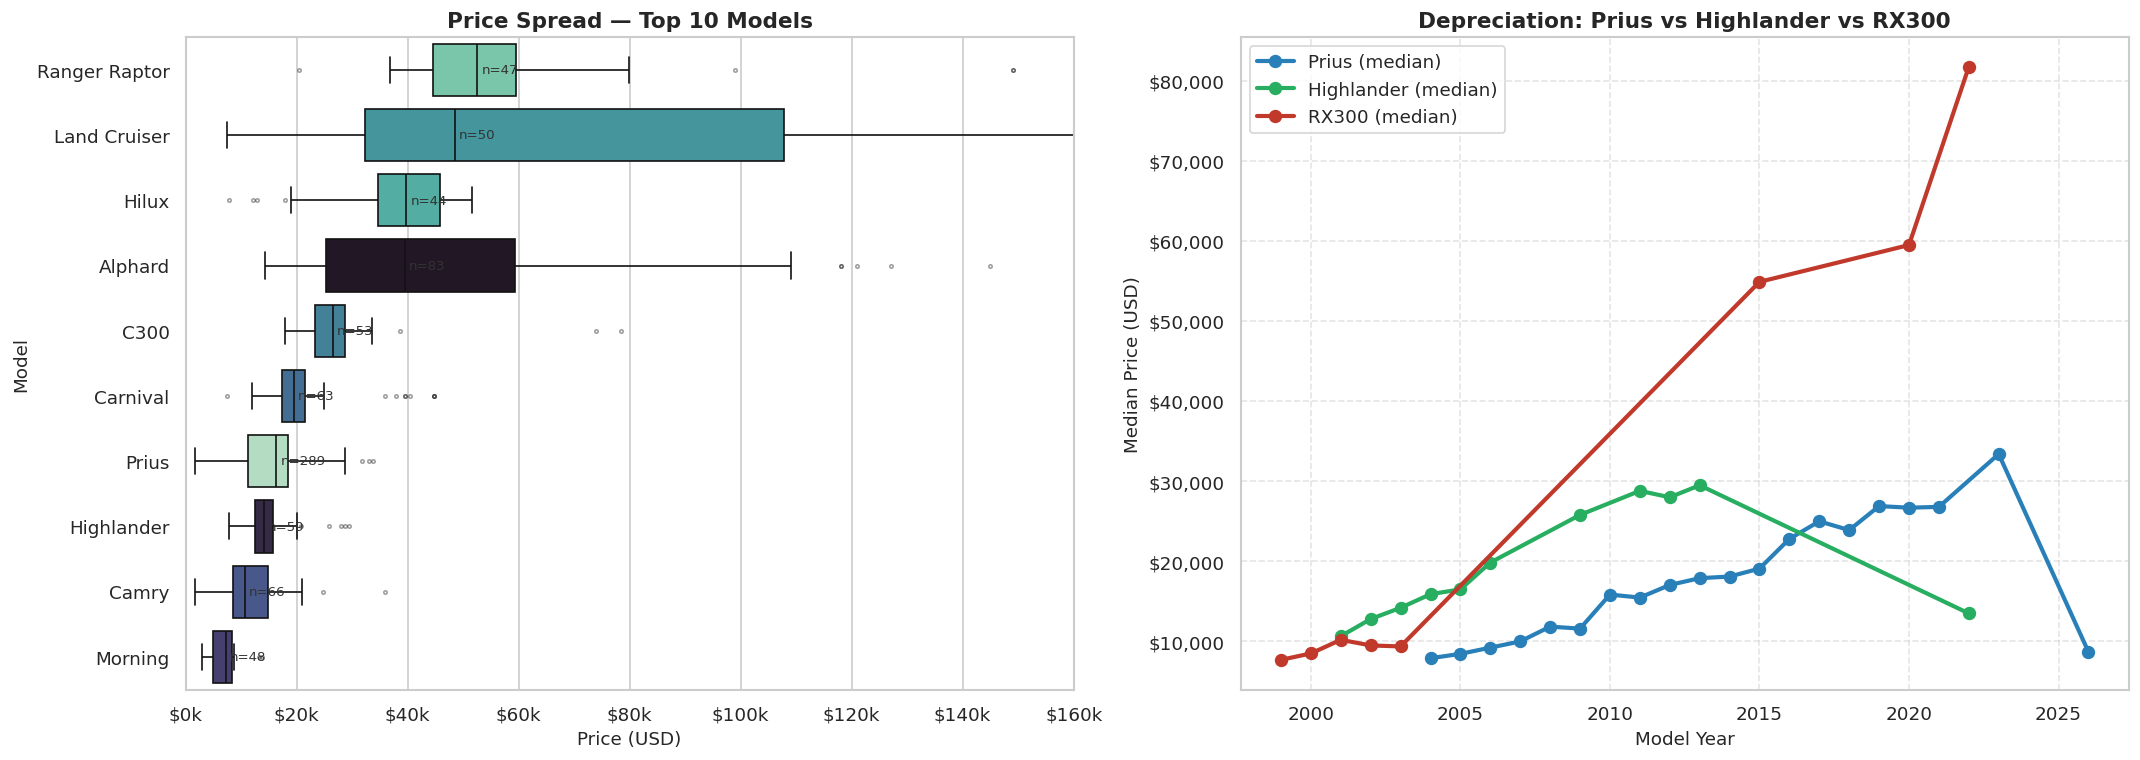

In [ ]:
# ── 7b. Top-10 Model Breakdown & Depreciation Comparison ────────────────────
known_models = df_eda[
    df_eda["vehicle_model"].notna() &
    ~df_eda["vehicle_model"].isin(["Unknown","Other",""])
]["vehicle_model"]
top10_models = known_models.value_counts().head(10).index.tolist()
df_top = df_eda[df_eda["vehicle_model"].isin(top10_models)]

model_order = df_top.groupby("vehicle_model")["price"].median().sort_values(ascending=False).index

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6.5))

# 1. Price spread — top 10 models
sns.boxplot(data=df_top, x="price", y="vehicle_model", order=model_order,
            hue="vehicle_model", legend=False, ax=ax1, palette="mako_r",
            flierprops=dict(marker=".", ms=4, alpha=0.4))
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax1.set_title("Price Spread — Top 10 Models")
ax1.set_xlabel("Price (USD)"); ax1.set_ylabel("Model")
ax1.set_xlim(0, 160_000)

# Annotate median & count
for i, model in enumerate(model_order):
    sub = df_top[df_top["vehicle_model"] == model]
    med = sub["price"].median()
    cnt = len(sub)
    ax1.text(med + 800, i, f"n={cnt}", va="center", fontsize=8, color="#333")

# 2. Depreciation curves — top 3 high-volume models
compare_models = [m for m in ["Prius","Highlander","RX300"] if m in df_eda["vehicle_model"].values]
colors2 = ["#2980b9","#27ae60","#c0392b"]
for model_name, col in zip(compare_models, colors2):
    sub = (df_eda[df_eda["vehicle_model"] == model_name]
           .groupby("vehicle_model_year")["price"].median())
    if len(sub) >= 3:
        ax2.plot(sub.index, sub.values, marker="o", label=f"{model_name} (median)",
                 color=col, lw=2.5, ms=7)

ax2.set_title("Depreciation: Prius vs Highlander vs RX300")
ax2.set_xlabel("Model Year"); ax2.set_ylabel("Median Price (USD)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.grid(True, ls="--", alpha=0.5); ax2.legend()

plt.tight_layout()
# plt.savefig(os.path.join(REPORTS_DIR, "04_model_breakdown.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## 8. Brand Pricing Hierarchy & Tax Status Premium

### 8a. Price Spread Across Top 10 Brands
### 8b. Tax Paper vs Plate Number Over Recent Model Years


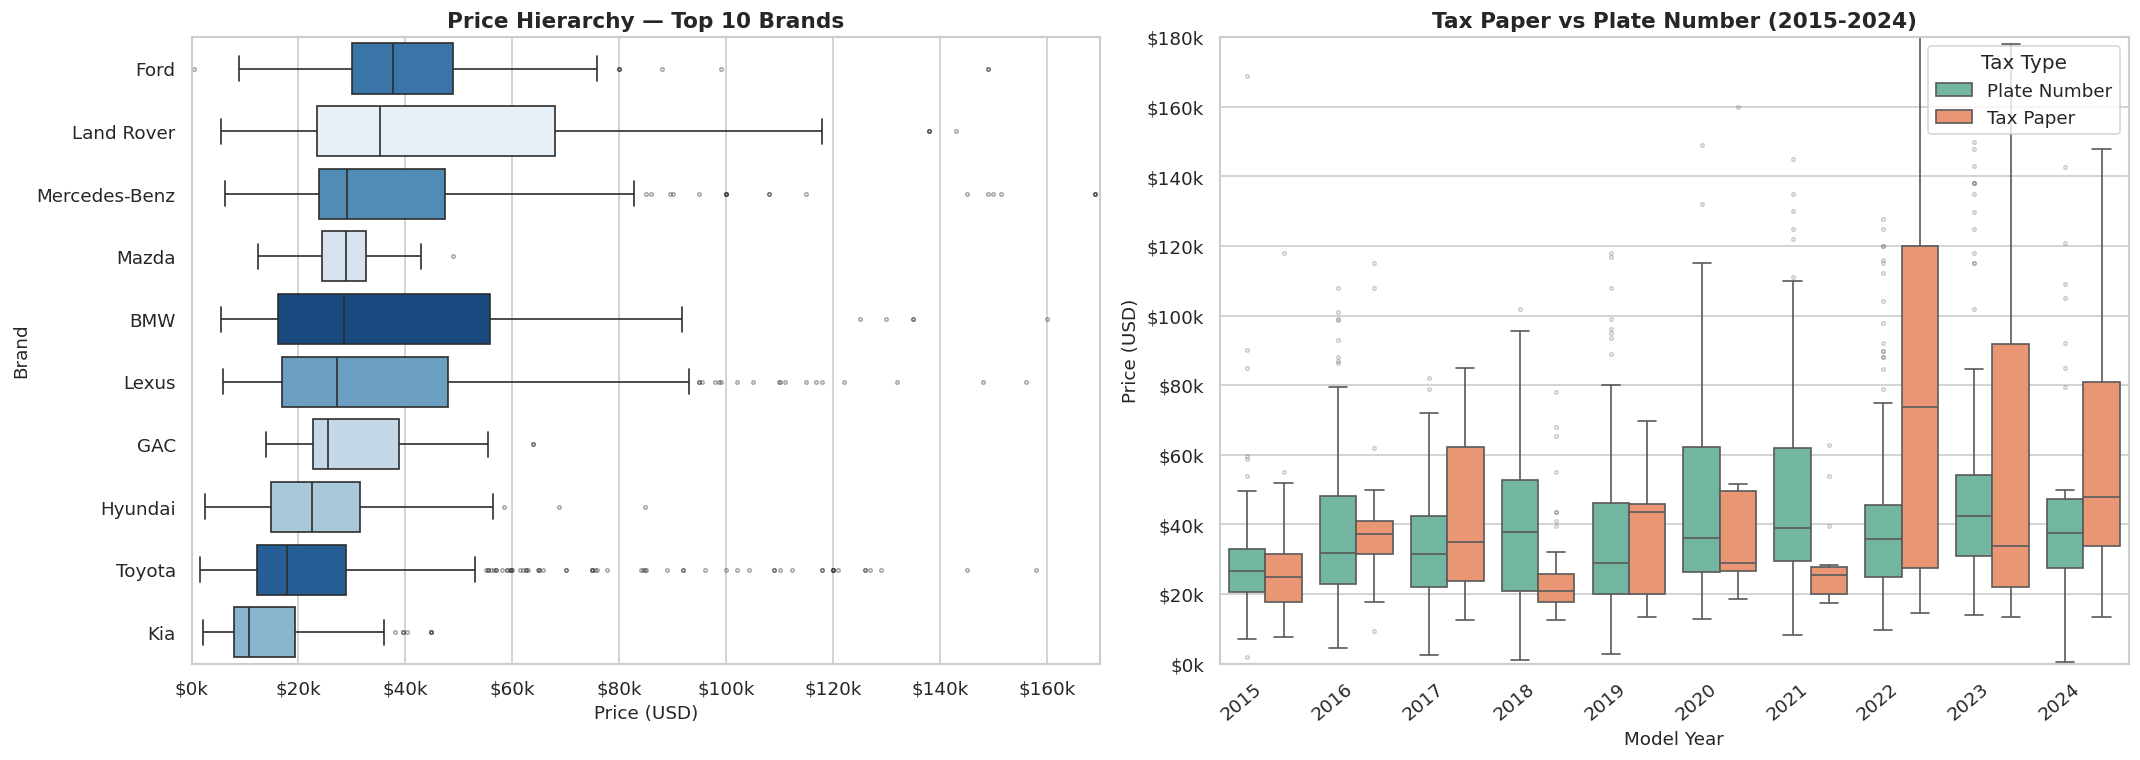

In [ ]:
# ── 8. Brand Hierarchy & Tax Premium ─────────────────────────────────────────
top10_brands = (df_eda[df_eda["vehicle_brand"] != "Unknown"]
                ["vehicle_brand"].value_counts().head(10).index)
df_tb = df_eda[df_eda["vehicle_brand"].isin(top10_brands)]
brand_order = df_tb.groupby("vehicle_brand")["price"].median().sort_values(ascending=False).index

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6.5))

# 1. Price by brand
sns.boxplot(data=df_tb, x="price", y="vehicle_brand", order=brand_order,
            hue="vehicle_brand", legend=False, ax=ax1, palette="Blues_r",
            flierprops=dict(marker=".", ms=4, alpha=0.4))
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax1.set_title("Price Hierarchy — Top 10 Brands")
ax1.set_xlabel("Price (USD)"); ax1.set_ylabel("Brand")
ax1.set_xlim(0, 170_000)

# 2. Tax type by model year (2015-2024)
recent = df_eda[df_eda["vehicle_model_year"].between(2015, 2024)]
tax_types = [t for t in ["Tax Paper","Plate Number"] if t in recent["vehicle_tax_type"].values]
sns.boxplot(data=recent[recent["vehicle_tax_type"].isin(tax_types)],
            x="vehicle_model_year", y="price", hue="vehicle_tax_type",
            ax=ax2, palette="Set2",
            flierprops=dict(marker=".", ms=4, alpha=0.3))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax2.set_title("Tax Paper vs Plate Number (2015-2024)")
ax2.set_xlabel("Model Year"); ax2.set_ylabel("Price (USD)")
ax2.set_ylim(0, 180_000); ax2.legend(title="Tax Type")
plt.setp(ax2.get_xticklabels(), rotation=40, ha="right")

plt.tight_layout()
# plt.savefig(os.path.join(REPORTS_DIR, "05_brand_tax_premium.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## 9. Equipment Options, Location Tiers & Seller Type Pricing


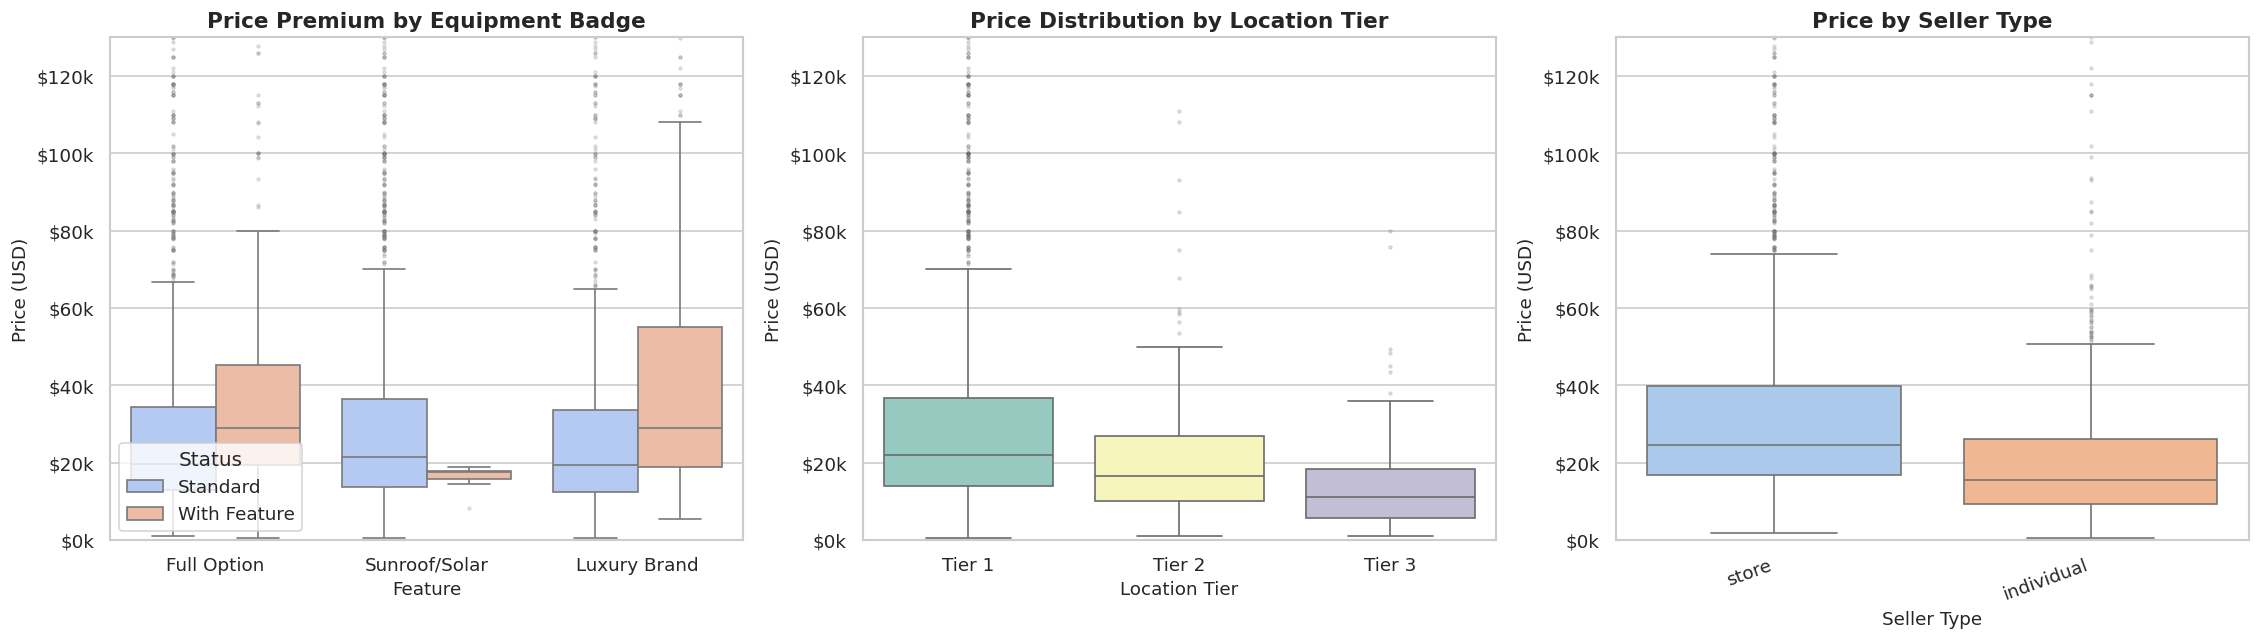

In [ ]:
# ── 9. Options, Location, Seller Dynamics ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# 1. Equipment badge premiums — stacked option comparison
option_rows = []
for flag, label in [("has_full_option","Full Option"),
                    ("has_sunroof_solar","Sunroof/Solar"),
                    ("is_luxury_brand","Luxury Brand")]:
    for v, status in [(0,"Standard"),(1,"With Feature")]:
        for p in df_eda[df_eda[flag]==v]["price"]:
            option_rows.append({"Feature": label, "Status": status, "Price": p})
df_opt = pd.DataFrame(option_rows)
sns.boxplot(data=df_opt, x="Feature", y="Price", hue="Status",
            ax=axes[0], palette="coolwarm",
            flierprops=dict(marker=".", ms=3, alpha=0.3))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[0].set_title("Price Premium by Equipment Badge")
axes[0].set_ylim(0, 130_000); axes[0].set_ylabel("Price (USD)")

# 2. Location tier pricing
sns.boxplot(data=df_eda, x="location_tier", y="price", hue="location_tier",
            order=["Tier 1","Tier 2","Tier 3"], legend=False,
            ax=axes[1], palette="Set3",
            flierprops=dict(marker=".", ms=3, alpha=0.3))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[1].set_title("Price Distribution by Location Tier")
axes[1].set_xlabel("Location Tier"); axes[1].set_ylabel("Price (USD)")
axes[1].set_ylim(0, 130_000)

# 3. Seller type pricing
seller_order = df_eda.groupby("seller_type")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df_eda, x="seller_type", y="price", hue="seller_type",
            order=seller_order, legend=False,
            ax=axes[2], palette="pastel",
            flierprops=dict(marker=".", ms=3, alpha=0.3))
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[2].set_title("Price by Seller Type")
axes[2].set_xlabel("Seller Type"); axes[2].set_ylabel("Price (USD)")
axes[2].set_ylim(0, 130_000)
plt.setp(axes[2].get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
# plt.savefig(os.path.join(REPORTS_DIR, "06_options_location_seller.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## 10. Market Liquidity Analysis

We examine how quickly cars sell (`days_on_market`), how much attention they attract (`view_count`),
and whether listing source (Individual vs Store) affects these dynamics.


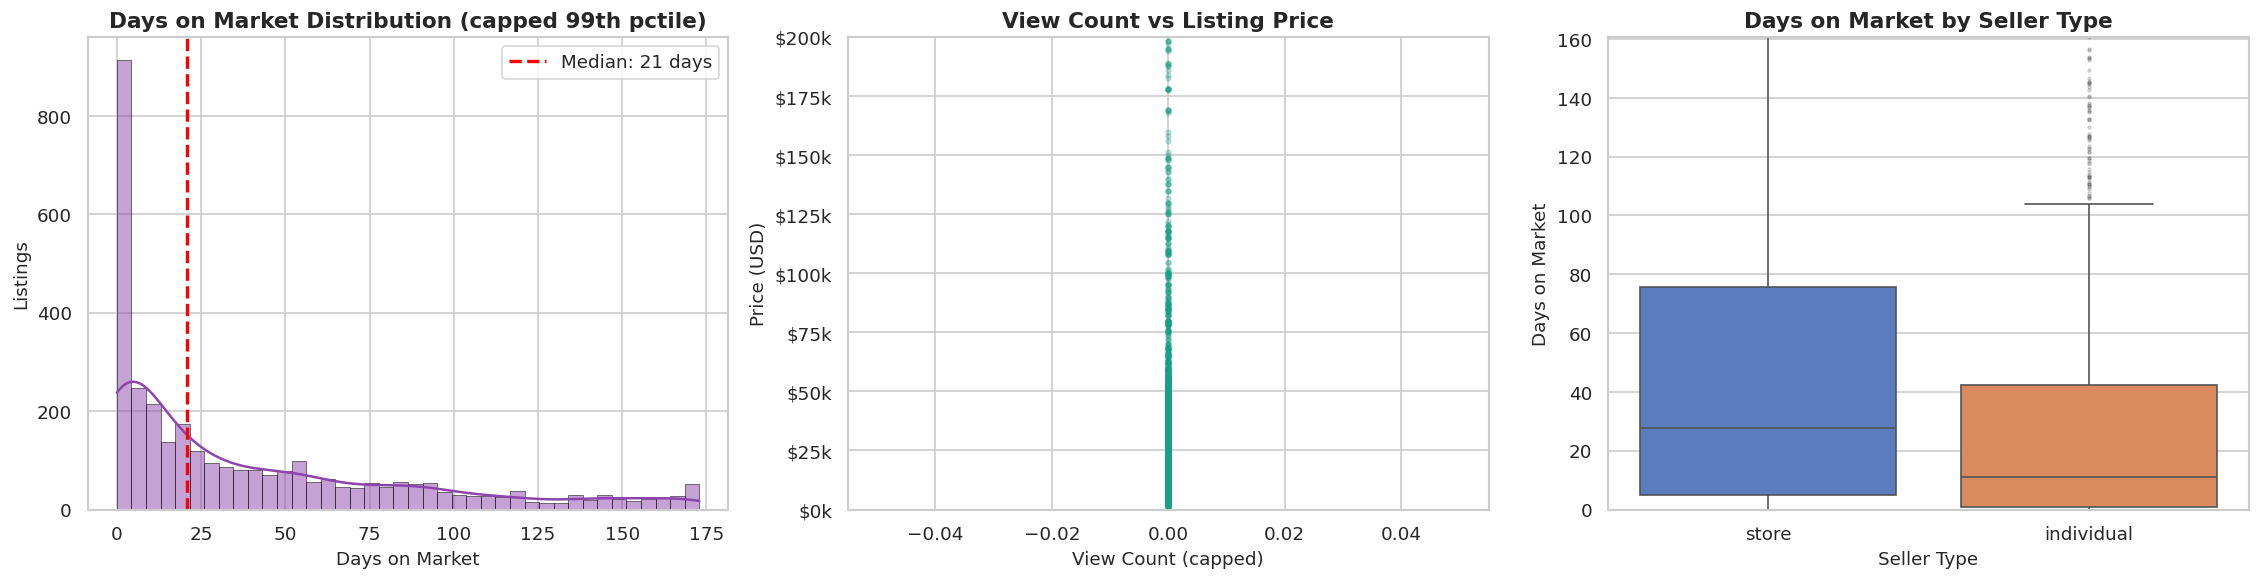

Days on Market — Summary:
count    3330.0
mean       40.6
std        46.7
min         0.0
25%         3.0
50%        20.8
75%        63.6
90%       113.9
99%       172.9
max       198.6


In [ ]:
# ── 10. Market Liquidity Analysis ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# 1. Days on Market distribution
dom = df_eda["days_on_market"].clip(upper=df_eda["days_on_market"].quantile(0.99))
sns.histplot(dom, bins=40, kde=True, ax=axes[0], color="#8e44ad", edgecolor="black", linewidth=0.3)
axes[0].axvline(dom.median(), color="red", ls="--", lw=2,
                label=f"Median: {dom.median():.0f} days")
axes[0].set_title("Days on Market Distribution (capped 99th pctile)")
axes[0].set_xlabel("Days on Market"); axes[0].set_ylabel("Listings")
axes[0].legend()

# 2. View count vs Price (log-log)
vc = df_eda["view_count"].clip(upper=df_eda["view_count"].quantile(0.99))
axes[1].scatter(vc, df_eda["price"],
                alpha=0.25, s=8, color="#16a085")
axes[1].set_xlabel("View Count (capped)"); axes[1].set_ylabel("Price (USD)")
axes[1].set_title("View Count vs Listing Price")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
axes[1].set_ylim(0, 200_000)

# 3. Days on Market by Seller Type
seller_types = df_eda["seller_type"].value_counts().index[:4]
dom_data = df_eda[df_eda["seller_type"].isin(seller_types)]
sns.boxplot(data=dom_data, x="seller_type", y="days_on_market", hue="seller_type",
            order=seller_types, legend=False, ax=axes[2], palette="muted",
            flierprops=dict(marker=".", ms=3, alpha=0.3))
axes[2].set_title("Days on Market by Seller Type")
axes[2].set_xlabel("Seller Type"); axes[2].set_ylabel("Days on Market")
axes[2].set_ylim(0, df_eda["days_on_market"].quantile(0.97))

plt.tight_layout()
# plt.savefig(os.path.join(REPORTS_DIR, "07_liquidity_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

# Numeric summary
print("Days on Market — Summary:")
print(df_eda["days_on_market"].describe(percentiles=[.25,.50,.75,.90,.99]).round(1).to_string())


---
## 11. Statistical Hypothesis Testing

We use **non-parametric tests** (no normality assumption) to confirm whether observed price differences
are statistically significant.

| Test | Variables | Method |
|---|---|---|
| Tax Status | Tax Paper vs Plate Number | Mann-Whitney U |
| Full Option | With vs Without | Mann-Whitney U |
| Location | Tier 1 vs Tier 2 vs Tier 3 | Kruskal-Wallis H |
| Seller Type | Individual vs Store | Mann-Whitney U |


In [13]:
# ── 11. Statistical Hypothesis Tests ──────────────────────────────────────────
results = []

def mwu(name, groupA, groupB, labA, labB):
    stat, p = stats.mannwhitneyu(groupA, groupB, alternative="two-sided")
    medA, medB = groupA.median(), groupB.median()
    diff = medA - medB
    results.append({
        "Test":       name,
        "Method":     "Mann-Whitney U",
        f"Median {labA}": f"${medA:,.0f}",
        f"Median {labB}": f"${medB:,.0f}",
        "Median Diff": f"${diff:+,.0f}",
        "Statistic":  f"U={stat:,.0f}",
        "p-value":    p,
        "Significant": "YES" if p < 0.05 else "NO",
    })

def kw(name, *groups):
    stat, p = stats.kruskal(*groups)
    results.append({
        "Test":       name,
        "Method":     "Kruskal-Wallis H",
        "Statistic":  f"H={stat:.2f}",
        "p-value":    p,
        "Significant": "YES" if p < 0.05 else "NO",
    })

# ── Test 1: Tax Status ─────────────────────────────────────────────────────────
tp = df_eda[df_eda["vehicle_tax_type"] == "Tax Paper"]["price"]
pn = df_eda[df_eda["vehicle_tax_type"] == "Plate Number"]["price"]
if len(tp) >= 5 and len(pn) >= 5:
    mwu("Tax Paper vs Plate Number", tp, pn, "Tax Paper", "Plate Number")

# ── Test 2: Full Option Premium ────────────────────────────────────────────────
fo = df_eda[df_eda["has_full_option"] == 1]["price"]
st = df_eda[df_eda["has_full_option"] == 0]["price"]
if len(fo) >= 5:
    mwu("Full Option Premium", fo, st, "Full Option", "Standard")

# ── Test 3: Location Tiers ─────────────────────────────────────────────────────
t1 = df_eda[df_eda["location_tier"] == "Tier 1"]["price"]
t2 = df_eda[df_eda["location_tier"] == "Tier 2"]["price"]
t3 = df_eda[df_eda["location_tier"] == "Tier 3"]["price"]
if len(t1) >= 5 and len(t2) >= 5 and len(t3) >= 5:
    kw("Location Tier (Tier1/2/3)", t1, t2, t3)

# ── Test 4: Seller Type ────────────────────────────────────────────────────────
indiv = df_eda[df_eda["seller_type"] == "individual"]["price"]
store = df_eda[df_eda["seller_type"] == "store"]["price"]
if len(indiv) >= 5 and len(store) >= 5:
    mwu("Individual vs Store Seller", store, indiv, "Store", "Individual")

# ── Display Results ────────────────────────────────────────────────────────────
print("=" * 70)
print("Statistical Hypothesis Testing Results (alpha = 0.05):")
print("=" * 70)
for r in results:
    print()
    print(f"  Test        : {r['Test']}")
    print(f"  Method      : {r['Method']}")
    print(f"  Statistic   : {r['Statistic']}")
    print(f"  p-value     : {r['p-value']:.4e}")
    print(f"  Significant : {r['Significant']}")
    for k, v in r.items():
        if k.startswith("Median"):
            print(f"  {k:<26}: {v}")
print("=" * 70)


Statistical Hypothesis Testing Results (alpha = 0.05):

  Test        : Tax Paper vs Plate Number
  Method      : Mann-Whitney U
  Statistic   : U=1,424,626
  p-value     : 2.7461e-20
  Significant : YES
  Median Tax Paper          : $24,500
  Median Plate Number       : $19,500
  Median Diff               : $+5,000

  Test        : Full Option Premium
  Method      : Mann-Whitney U
  Statistic   : U=906,977
  p-value     : 7.9997e-22
  Significant : YES
  Median Full Option        : $28,877
  Median Standard           : $19,800
  Median Diff               : $+9,077

  Test        : Location Tier (Tier1/2/3)
  Method      : Kruskal-Wallis H
  Statistic   : H=71.56
  p-value     : 2.8930e-16
  Significant : YES

  Test        : Individual vs Store Seller
  Method      : Mann-Whitney U
  Statistic   : U=1,677,136
  p-value     : 5.3748e-68
  Significant : YES
  Median Store              : $24,525
  Median Individual         : $15,625
  Median Diff               : $+8,900


---
## 12. Correlation Analysis & Feature Ranking

Pearson correlations between numeric/binary proxy features and the target `log_price`.


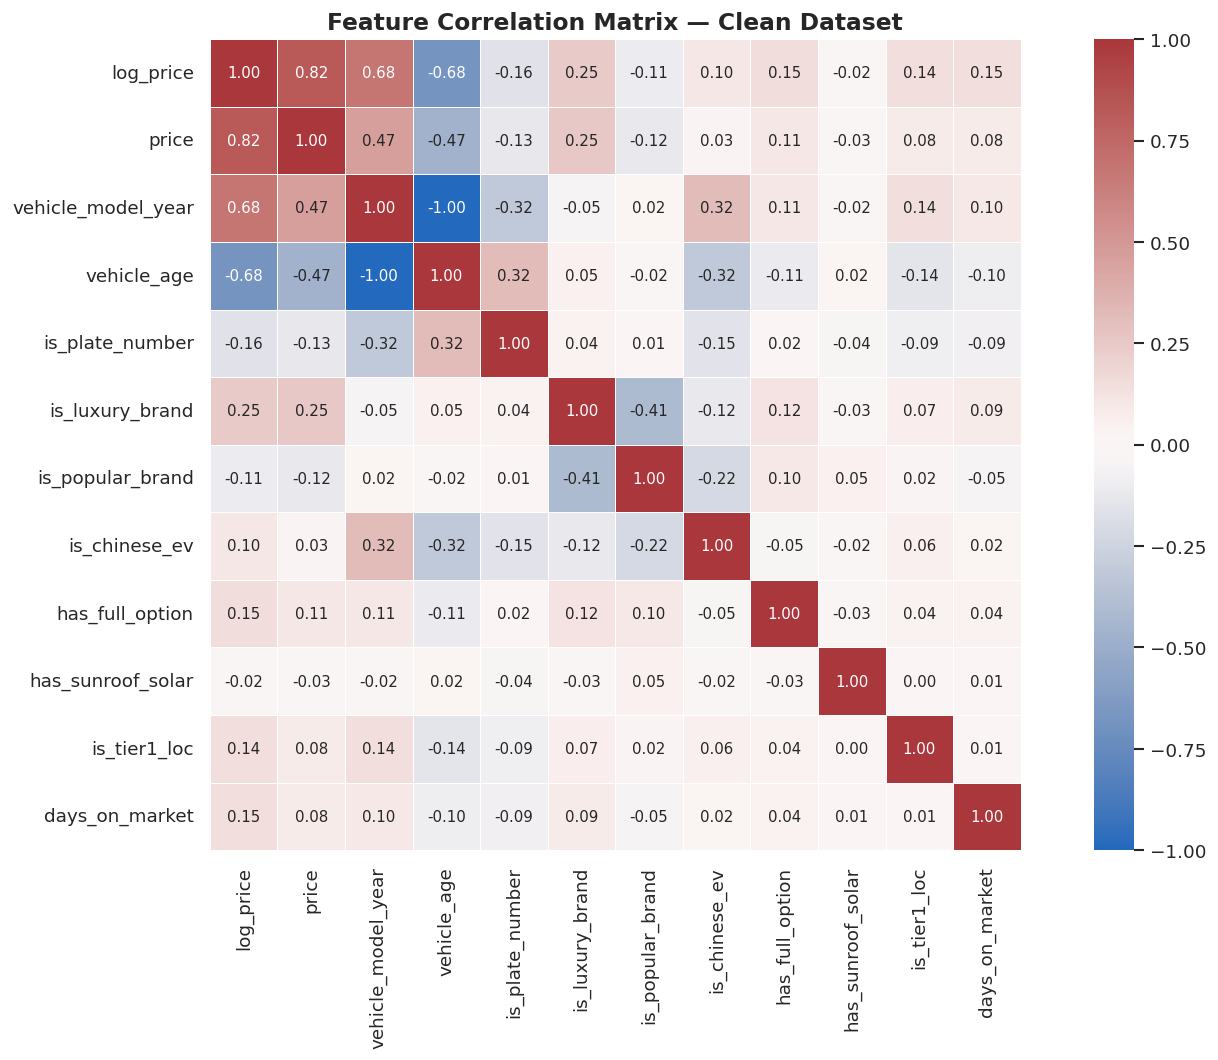

Feature Correlation with Target (log_price):
  vehicle_model_year         : +0.684  +#############
  is_luxury_brand            : +0.247  +####
  has_full_option            : +0.153  +###
  days_on_market             : +0.147  +##
  is_tier1_loc               : +0.144  +##
  is_chinese_ev              : +0.102  +##
  has_sunroof_solar          : -0.025  -
  is_popular_brand           : -0.109  -##
  is_plate_number            : -0.162  -###
  vehicle_age                : -0.684  -#############


In [14]:
# ── 12. Correlation Heatmap & Feature Ranking ────────────────────────────────
corr_candidates = [
    "log_price", "price",
    "vehicle_model_year", "vehicle_age",
    "is_plate_number",
    "is_luxury_brand", "is_popular_brand", "is_chinese_ev",
    "has_full_option", "has_sunroof_solar",
    "is_tier1_loc",
    "days_on_market", "view_count",
]
corr_cols = [c for c in corr_candidates if c in df_eda.columns and df_eda[c].std() > 0]
corr_mat = df_eda[corr_cols].corr()

plt.figure(figsize=(13, 9))
mask = np.zeros_like(corr_mat, dtype=bool)
# Show full matrix (no mask) for visibility
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1,
            square=True, linewidths=0.5, annot_kws={"size": 9})
plt.title("Feature Correlation Matrix — Clean Dataset", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "08_correlation_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Feature Ranking (vs log_price) ────────────────────────────────────────────
print("=" * 52)
print("Feature Correlation with Target (log_price):")
print("=" * 52)
ranked = corr_mat["log_price"].dropna().sort_values(ascending=False)
for feat, score in ranked.items():
    if feat not in ["log_price", "price"]:
        bar = "#" * int(abs(score) * 20)
        direction = "+" if score >= 0 else "-"
        print(f"  {feat:<26} : {score:+.3f}  {direction}{bar}")
print("=" * 52)


---
## 13. Executive Summary & Hand-Off to Phase 4 Modeling

### Key Market Findings

| # | Finding | Evidence |
|---|---|---|
| 1 | **Price is highly right-skewed** | Raw skew ≈ 3.4; log-transform reduces to ≈ 0.2 — essential for regression stability |
| 2 | **Vehicle age is the dominant price driver** | Pearson r ≈ −0.68 with log_price; steep decay in first 5 years |
| 3 | **Tax Paper commands a premium** | Statistically significant (p < 0.001); Tax Paper cars are newer imports, less depreciated |
| 4 | **Full Option badge adds verified value** | Statistically significant (p < 0.05) |
| 5 | **Brand concentration** | Toyota + Lexus account for ~36% of all listings |
| 6 | **Phnom Penh dominates** | Tier 1 (Phnom Penh) holds ~70%+ of listings with higher median prices |

### Features Validated for Phase 4 ML Modeling

```
Numeric    : vehicle_age, vehicle_age_squared, imputed_mileage_km, vehicle_engine_cc
Binary     : is_plate_number, is_luxury_brand, is_popular_brand, is_chinese_ev,
             has_full_option, is_tier1_loc, is_mileage_missing
Categorical: brand_tier, location_tier, vehicle_fuel_type, vehicle_transmission,
             vehicle_condition, seller_type
Target     : log_price  (→ expm1() to recover USD price at inference)
```

### Next: `notebooks/03_baseline_models.ipynb`
- Ridge / Lasso / ElasticNet linear baselines
- Random Forest & Extra Trees ensemble
- LightGBM / XGBoost / CatBoost gradient boosters
- Cross-validated RMSE on `log_price`, back-converted to MAPE in USD
